# Detecting and Dealing with Outliers

By definition, outliers are extreme values, which deviates from other observations on data. More formally it can be defined as:


### Why should outliers  be treated with caution? 

Cases in which we do not like outliers:

* Outliers distort the characteristics of data. For instance, consider the central tendency of a variable. Mean is one of the most widely used central tendenct statistics but it suffers from outliers.
* Some machine learning models are sensitive to extreme values. Therefore, in order to get accurate estimates, we need to subtract these values from our dataset.

Cases in which we do like outliers:

* Anomaly detection. In detecting anomalies, the focus of the researcher is on the outliers in the sense that outliers turn out to be an anomaly.

* Weather Prediction. Consider a case in which researchers would like to predict severe weather condition to set early warning alarm so that people can take precautionary measure to stay alive. This extreme conditions may refer to outliers.


### Visual Inspection

In order to detect outliers, we first utilize the visualization tools. These tools are:

* Histogram
* Boxplot

#### Histogram

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
import seaborn as sns
warnings.filterwarnings("ignore")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (10,5)

In [2]:
house_df = pd.read_csv('house_price.csv')

- House Prices are around gather between $\$100.000$ and $\$200.000$. By contrast, we have vey few observations over $700.000. 

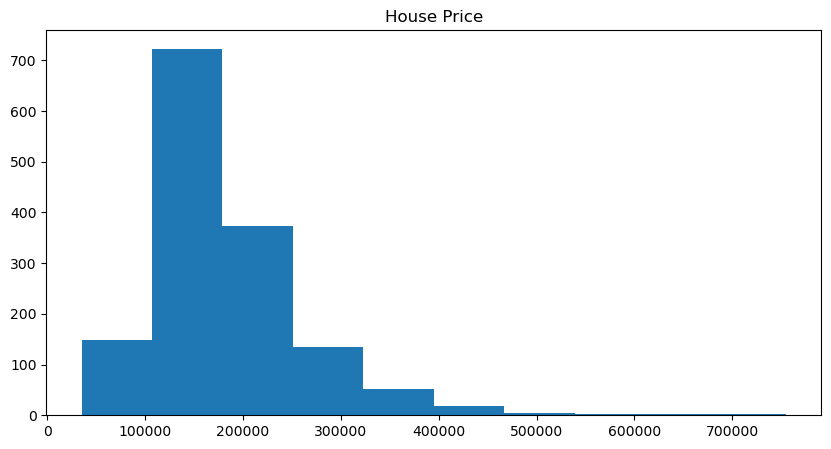

In [3]:
plt.hist(house_df['SalePrice'])
plt.title("House Price")
plt.show()

Then, how can we properly detect outliers using visualization technique? This is the point at which `boxplot` comes in. Boxplot is a tool specifically design to detect outliers. Let's see how it works now!

#### Boxplot

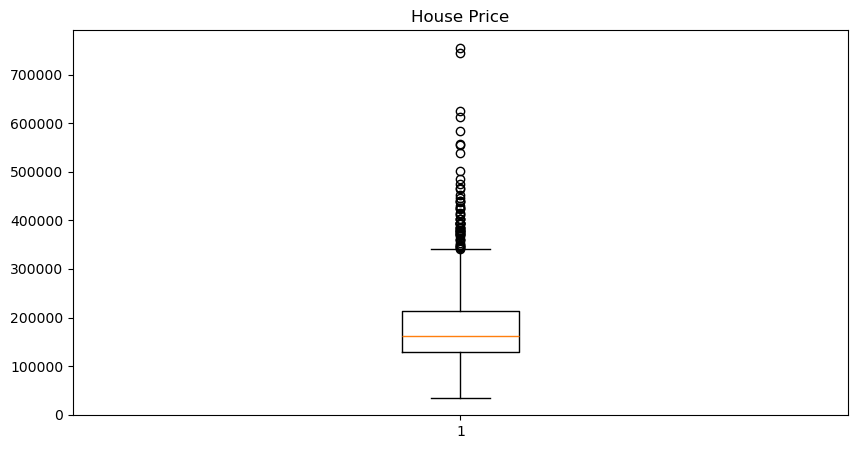

In [4]:
plt.boxplot(house_df['SalePrice'])
plt.title("House Price")
plt.show()

Do you see the circle towards the upper bound of the `sale price` dataset. This circles represent the outliers. This indicates that `sale price` variable has outliers on the upper bound, which can be confirmed by checking the histogram. The observations locating the far away from the mean gather around the right tail representing the upper bound. On the left tail of the histogram, the observations are far more closer to the mean of `sale price` implying that there is no outliers on the lower bound of the data.

Please note that box plot, also called `Box-Whisker` plot, are based on interquartile intervals and have whiskers. The data points lying beyond the whiskers are called fliers and are generally considered to be outliers. In Matplotlib, by default, whiskers reach a standard deviation of 1.5 times away from the first and third quarters, but we can check this using the `whis` parameter. So let's redraw the box plot for sale price and see how the number of outliers change based on `whis` parameter:

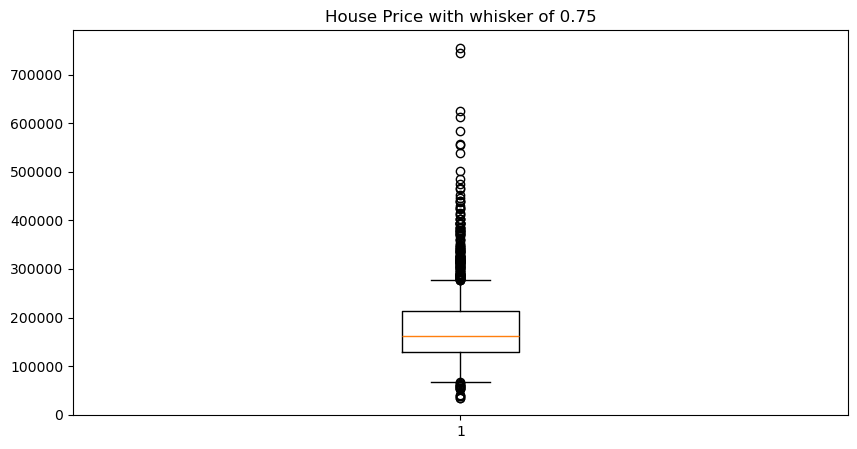

In [5]:
plt.boxplot(house_df['SalePrice'],whis=0.75)
plt.title("House Price with whisker of 0.75")
plt.show()

In the above-given boxplot, we reduce the whisker parameter to 0.75 and it turns out that number of outliers has increased. Moreover, few outliers show up in the lower bound of the data. Now, let's see what happens if we increase the whisker parameter.

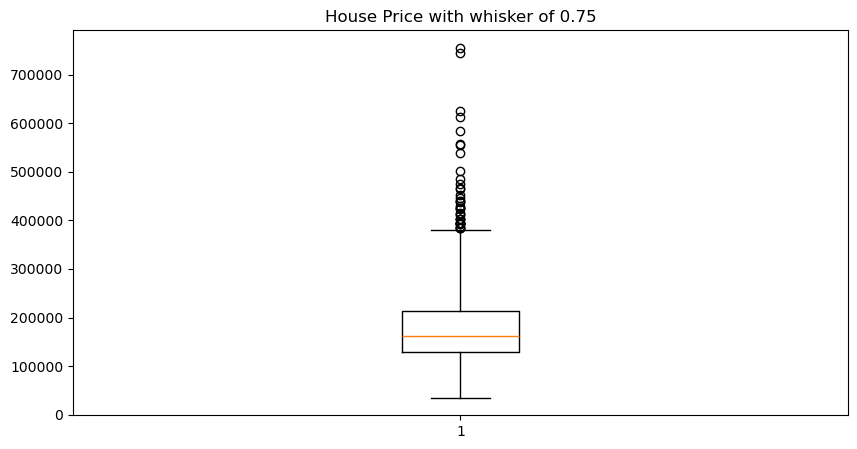

In [6]:
plt.boxplot(house_df['SalePrice'],whis=2)
plt.title("House Price with whisker of 0.75")
plt.show()

As expected, if we push whisker up, we end up with less and less outlier. At this point, it is worthwhile to observe what happens when the whisker takes an extreme value such as 8. The result is shown below and variable seems to be outlier-free, meaning that when detecting the outliers there is no single limit. Rather the limit beyond which we detect outliers should be identified case by case. Please do not forget, we are dealing with data and therefore we need data dependent strategies.

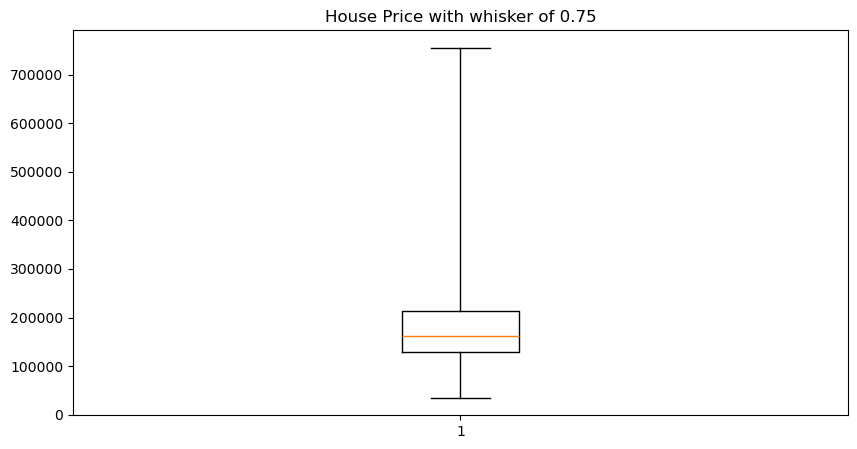

In [7]:
plt.boxplot(house_df['SalePrice'],whis=8)
plt.title("House Price with whisker of 0.75")
plt.show()

## Statistical Tools in Detecting the Outliers

So far, we have discussed visual way to detect outliers. However, there is statistical methods by which we can detect outliers. These statistical methods are:

* Z score
* Tuckey method

### Z score

- The `Z-Score` is a scaling technique by which we have a dataset with mean 0 and standard deviation of 1. 
- You can measure how far a value is far away from the mean (0) in terms of standard deviations (1). 
- The bigger the z-score of a value, the farther it is from the mean and the more likely that it is an outlier. 
- However, you still need to set a threshold for what z-score constitutes an outlier.

These scaled values indicate how many standard deviations the data is away from the mean. After this scaling, depending on the characteristics of the data, we can identify a threshold value beyond which the observation is thought to be an outlier. More specifically, in normal distribution, observation location **3** standard deviation away from the mean is generally considered as outliers.

let's know use z-score method to detect these outliers.

In [8]:
from scipy.stats import zscore

In [9]:
zscores = zscore(house_df["SalePrice"])

In [10]:
zscores

array([ 0.34727322,  0.00728832,  0.53615372, ...,  1.07761115,
       -0.48852299, -0.42084081], shape=(1460,))

### Let's use 3 as the threshold for outliers and find outlier points 

In [11]:
(zscores > 3).sum()

np.int64(22)

In [12]:
(zscores < -3).sum()

np.int64(0)

In [13]:
house_df["price_zscores"]=zscores

In [14]:
house_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,price_zscores
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2008,WD,Normal,208500,0.347273
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,5,2007,WD,Normal,181500,0.007288
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,9,2008,WD,Normal,223500,0.536154
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000,-0.515281
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,12,2008,WD,Normal,250000,0.869843


In [15]:
house_df.query("price_zscores > 3 ").sort_values(by="SalePrice").head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,price_zscores
664,665,20,RL,49.0,20896,Pave,NaN,IR2,Lvl,AllPub,...,NaN,NaN,NaN,0,1,2006,New,Partial,423000,3.048264
1142,1143,60,RL,77.0,9965,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,4,2007,New,Partial,424870,3.071811
389,390,60,RL,96.0,12474,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,NaN,0,8,2008,New,Partial,426000,3.086040
496,497,20,RL,NaN,12692,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,NaN,0,5,2007,WD,Normal,430000,3.136409
349,350,60,RL,56.0,20431,Pave,NaN,IR2,Lvl,AllPub,...,NaN,NaN,NaN,0,4,2006,New,Partial,437154,3.226492


### Houses having prices more than 423K can be considered outliers 

<Axes: xlabel='SalePrice', ylabel='Count'>

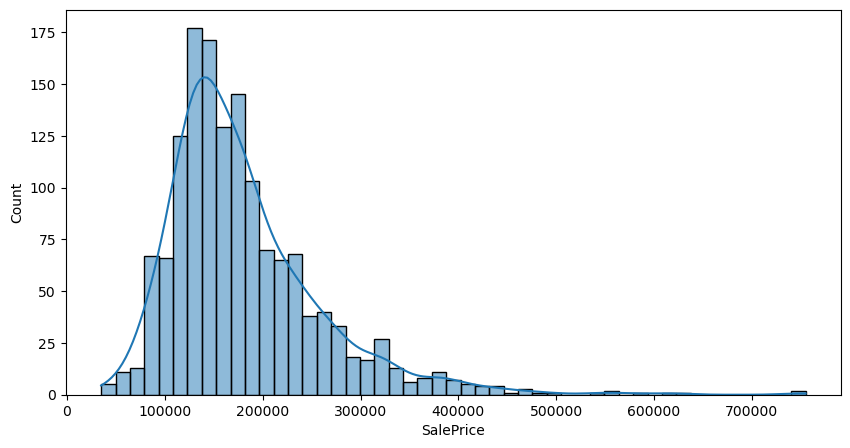

In [5]:
sns.histplot(house_df.SalePrice,kde=True)

### Tukey Method


This method is also known as the `Interquartile Interval (IQR)` method, and when we talk about the box plot method, we see this method in action. As we said earlier, IQR is the interval between the first and third quarters. This method evaluates all values that are 1.5 times the IQR as outliers. However, we can change the range and set another threshold value instead of 1.5.



Using the threshold values 1, 1.5, 2, ...., 4.5, let's find the number of outliers in the variable number_ displayed by `Tukey's` method: Here we use the `.percentile()` function in the Numpy library. This function returns the values that correspond to the parameters in percent to us. Let's assign the threshold values and the number of outliers to a data frame.

In [17]:
q75, q25 = np.percentile(house_df['SalePrice'],[75 ,25])
IQR = q75 - q25

In [18]:
q75

np.float64(214000.0)

In [19]:
q25

np.float64(129975.0)

### Let's find outliers using  1.5x IQR threshold 

In [20]:
upper_lim=q75+1.5*IQR;upper_lim

np.float64(340037.5)

In [21]:
lower_lim=q25-1.5*IQR;lower_lim

np.float64(3937.5)

### Find the outliers using this thresholds 

In [ ]:
# codes here

## Fixing the Outliers

* Extracting the outliers from the dataset.
* Limiting the outliers by assigning new values.
* Transforming the outliers so as to decrease their impact.

#### Excluding Outliers from the Dataset

Removing observations with excessive values is the easiest way to handle outliers. However, recall the fact that excluding outliers may mean to lose information. This is especially true for outliers in small datasets. However, the following situations may justify removing the outliers from the dataset:

* Outliers arising from measurement error or a problem in the data collection process, we must remove them.
* If subtracting outliers does not make any significant changes in later stages, we can remove them. However, in order to make sure, we must perform our analysis both with and without outliers.
* We can remove outliers from our dataset if we could not find a suitable way to handle them, even if subtracting outliers makes a meaningful change in the following stages.

### Limiting outliers: Winsorization

Winsorizing can be implemented in one-way or two-way.   
In one-sided winsorization, we limit either the lowest end of the distribution or the highest end.  
In both sides, we limit both the lowest and the highest end.

The idea in winsorizing is to adjust the values of the extreme points to a certain percentage.  
For example, we can set the values of the highest extreme of the distribution to 95 percentile.  
Similarly, we can set the values of the lowest extreme to 5 percentile.



We can winsorize a variable using scipy's `.winsorize()` method. In two-sided winsorization, we have given a group of values where the first element is the lowest percentage and the second element is the highest percentage. If we want to apply a one-side percentage, we can set the relevant item in this line to zero. Now, let's winsorize the duration variable. But, before doing that, let's examine the outliers in duration variable:

Let's apply the winsorizing technique and see how efficient it is. First, we draw the boxplot with the raw sale price variable to compare the result we get from winsorizing.

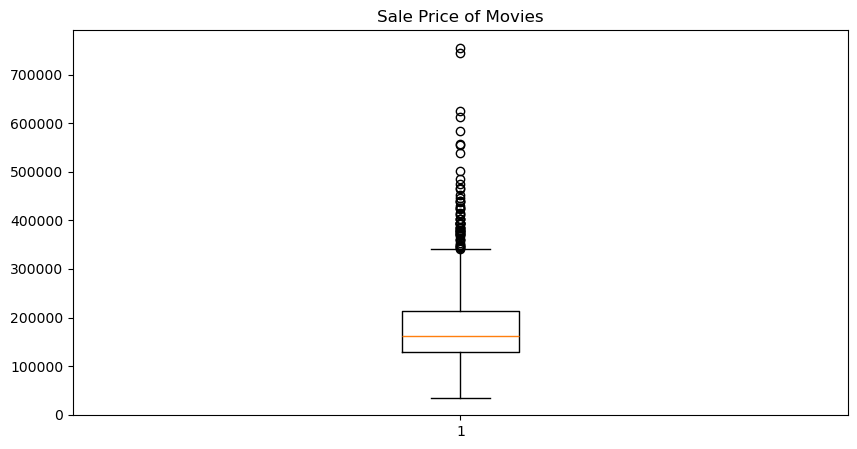

In [22]:
plt.boxplot(house_df['SalePrice'].dropna())
plt.title("Sale Price of Movies")
plt.show()

In [23]:
from scipy.stats.mstats import winsorize

winsorizing= winsorize(np.array(house_df['SalePrice'].dropna()), (0.10, 0.10))
winsorizing

masked_array(data=[208500, 181500, 223500, ..., 266500, 142125, 147500],
             mask=False,
       fill_value=999999)

In [24]:
house_df["price_winsorized"]=winsorizing

In [25]:
house_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,price_zscores,price_winsorized
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,0,2,2008,WD,Normal,208500,0.347273,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,NaN,NaN,0,5,2007,WD,Normal,181500,0.007288,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,0,9,2008,WD,Normal,223500,0.536154,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,0,2,2006,WD,Abnorml,140000,-0.515281,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,NaN,NaN,0,12,2008,WD,Normal,250000,0.869843,250000


In [26]:
house_df.SalePrice.describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [27]:
house_df.price_winsorized.describe()

count      1460.000000
mean     175076.632877
std       55250.944088
min      106500.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      278000.000000
Name: price_winsorized, dtype: float64

In [28]:
np.percentile(house_df.SalePrice,90)

np.float64(278000.0)

In [29]:
np.percentile(house_df.SalePrice,10)

np.float64(106475.0)

According to the above-given code, the 10% of the lowest value and the 10% of the highest values are replaced. Let's see if this strategy works!

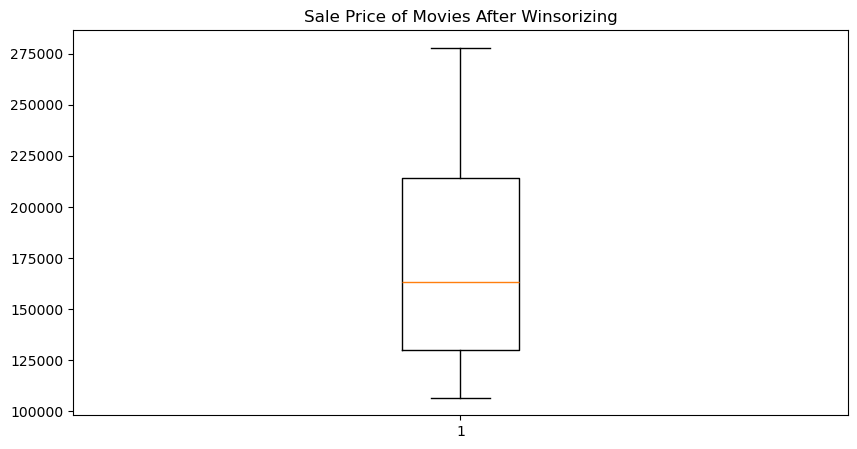

In [30]:
plt.boxplot(winsorizing)
plt.title("Sale Price of Movies After Winsorizing")
plt.show()

#### Transforming the Outliers

Another common way to deal with outliers is the Transforming the variable. The scaling helps us not only in dealing with the outliers, but also in detecting abnormal or near-normal distributions. When transforming the variable, we usually apply monotonic transformations. These transformations do not change the relative order of values in a variable. Log transformation and square root transformation are the most used transformations in data science.



To see the effect of the log transformation on the sale price variable, let's draw the histogram of the original variable and the log transformed version:

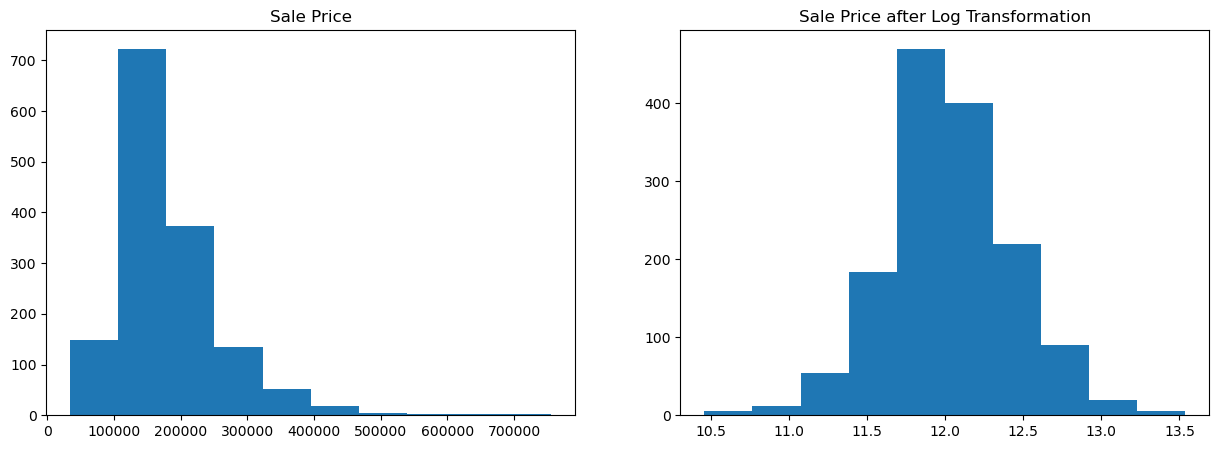

In [31]:
plt.figure(figsize = (15,5))

plt.subplot(1,2,1)
plt.hist(house_df['SalePrice'].dropna())
plt.title("Sale Price")

plt.subplot(1,2,2)
plt.hist(np.log(house_df['SalePrice'].dropna()))
plt.title("Sale Price after Log Transformation")
plt.show()

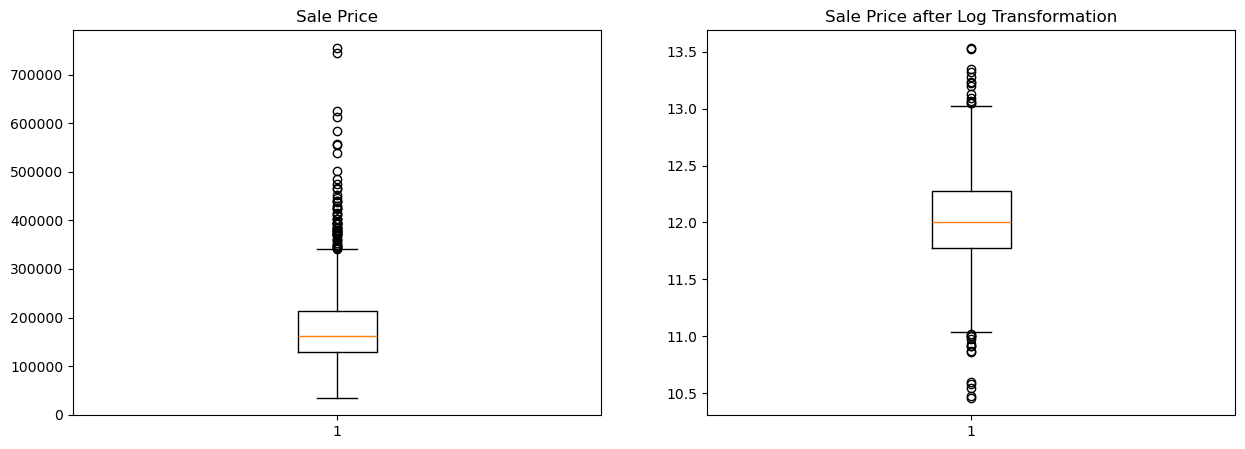

In [32]:
plt.figure(figsize = (15,5))

plt.subplot(1,2,1)
plt.boxplot(house_df['SalePrice'].dropna())
plt.title("Sale Price")

plt.subplot(1,2,2)
plt.boxplot(np.log(house_df['SalePrice'].dropna()))
plt.title("Sale Price after Log Transformation")
plt.show()

On the right-hand-side, we have the box plot of log transformed sale price and it seems that log transformation narrows the range of values so that the impact of outliers on the entire data decreases.